Dataset Organization

In [4]:
import os
import shutil
import re
from glob import glob
from collections import Counter

# ---------------------------
# CONFIG — adjust paths here
# ---------------------------
PROJECT_DIR = r"D:\Emotion Voice"
RAW_INPUTS = os.path.join(PROJECT_DIR, "Data", "raw_datasets")   # where your original dataset folders are
OUTPUT_DIR  = os.path.join(PROJECT_DIR, "Data", "raw")          # final emotion-wise output

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------------------------
# EMOTION LABELS (final)
# ---------------------------
EMOTIONS = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
for e in EMOTIONS:
    os.makedirs(os.path.join(OUTPUT_DIR, e), exist_ok=True)

# ---------------------------
# HELPERS
# ---------------------------
def copy_to_emotion(src_path, emotion):
    """Copy file to the corresponding emotion folder (skip duplicates)."""
    if emotion not in EMOTIONS:
        return
    dst_folder = os.path.join(OUTPUT_DIR, emotion)
    os.makedirs(dst_folder, exist_ok=True)
    dst = os.path.join(dst_folder, os.path.basename(src_path))
    if not os.path.exists(dst):
        shutil.copy2(src_path, dst)

# ---------------------------
# CREMA-D parsing
# filenames examples: 1001_DFA_ANG_XX.wav, 1002_IEO_HAP_XX.wav
# tokens use uppercase tags like _ANG_, _HAP_, _DIS_, _FEA_, _NEU_, _SAD_, _SUR_
# ---------------------------
cremad_dir = os.path.join(RAW_INPUTS, "CremaD")
if os.path.isdir(cremad_dir):
    pattern = re.compile(r'_(ANG|DIS|FEA|HAP|NEU|SAD|SUR)_', flags=re.IGNORECASE)
    for f in glob(os.path.join(cremad_dir, "*.wav")):
        m = pattern.search(os.path.basename(f))
        if m:
            code = m.group(1).upper()
            map_crema = {
                'ANG': 'angry',
                'DIS': 'disgust',
                'FEA': 'fear',
                'HAP': 'happy',
                'NEU': 'neutral',
                'SAD': 'sad',
                'SUR': 'surprise'
            }
            emotion = map_crema.get(code)
            copy_to_emotion(f, emotion)

# ---------------------------
# RAVDESS parsing
# example file format: 03-01-05-01-01-01-01.wav
# third field is Emotion code: 01=neutral,03=happy,05=angry,06=fear,07=disgust,08=surprise,04=sad,02=calm -> treat calm as neutral
# ---------------------------
ravdess_base = os.path.join(RAW_INPUTS, "RAVDESS", "Audio_Speech_Actors_01-24")
if os.path.isdir(ravdess_base):
    rav_map = {
        '01': 'neutral', '02': 'neutral', '03': 'happy', '04': 'sad',
        '05': 'angry', '06': 'fear',    '07': 'disgust', '08': 'surprise'
    }
    for f in glob(os.path.join(ravdess_base, "Actor_*", "*.wav")):
        fname = os.path.basename(f)
        parts = fname.split('-')
        if len(parts) >= 3:
            code = parts[2]
            emotion = rav_map.get(code)
            if emotion:
                copy_to_emotion(f, emotion)

# ---------------------------
# SAVEE parsing
# examples: DC_a01.wav  (a=angry, d=disgust, f=fear, h=happy, n=neutral, s=sad, su=surprise not used)
# SAVEE uses a single-letter label at 3rd char in many files
# be careful: check pattern DC_xxx.wav where x is label
# ---------------------------
savee_dir = os.path.join(RAW_INPUTS, "SAVEE")
if os.path.isdir(savee_dir):
    # create map for single-letter codes
    savee_map = {
        'a': 'angry',
        'd': 'disgust',
        'f': 'fear',
        'h': 'happy',
        'n': 'neutral',
        's': 'sad'
        # ('u' not used in SAVEE)
    }
    for f in glob(os.path.join(savee_dir, "*.wav")):
        base = os.path.basename(f).lower()
        # match DC_x or other patterns: attempt to find underscore + letter pattern like "_a"
        # fallback: third char if filename like "DC_a01.wav"
        m = re.search(r'[_-]([adfhnmsu])\w*\.\w+$', base)
        if m:
            code = m.group(1)
            emotion = savee_map.get(code)
            if emotion:
                copy_to_emotion(f, emotion)
        else:
            # fallback: try third character (common DC_a01.wav)
            if len(base) > 3:
                code = base[3]
                emotion = savee_map.get(code)
                if emotion:
                    copy_to_emotion(f, emotion)

# ---------------------------
# TESS parsing
# TESS has folders e.g., OAF_angry, OAF_happy etc.
# ---------------------------
tess_dir = os.path.join(RAW_INPUTS, "TESS")
if os.path.isdir(tess_dir):
    for sub in glob(os.path.join(tess_dir, "*")):
        if os.path.isdir(sub):
            foldername = os.path.basename(sub).lower()
            # find emotion token in folder name
            for emo in EMOTIONS:
                if emo in foldername:
                    for f in glob(os.path.join(sub, "*.wav")):
                        copy_to_emotion(f, emo)
                    break

# ---------------------------
# REPORT: counts per emotion
# ---------------------------
counts = {}
for emo in EMOTIONS:
    folder = os.path.join(OUTPUT_DIR, emo)
    counts[emo] = len(glob(os.path.join(folder, "*.wav")))
print("Merge complete. File counts by emotion:")
for emo, cnt in counts.items():
    print(f"  {emo:8s}: {cnt}")


Merge complete. File counts by emotion:
  angry   : 1863
  disgust : 1863
  fear    : 1863
  happy   : 1863
  neutral : 1775
  sad     : 1863
  surprise: 592


In [5]:
import os
import random
from collections import defaultdict

# Path to your merged dataset root folder
BASE_DIR = "Data/raw"

# Expected emotion categories
emotions = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]

# Function to detect which dataset a file might belong to (based on filename patterns)
def detect_dataset(filename):
    if "Actor_" in filename or filename.startswith("03-01"):  # RAVDESS pattern
        return "RAVDESS"
    elif filename.startswith("OAF_") or filename.startswith("YAF_"):  # TESS pattern
        return "TESS"
    elif filename.split("_")[0].isdigit() and len(filename.split("_")[0]) == 4:  # CREMA-D pattern
        return "CREMA-D"
    elif filename.lower().startswith(("a", "d", "f", "h", "n", "sa", "su")):  # SAVEE pattern
        return "SAVEE"
    else:
        return "Unknown"

# Count and verify structure
file_counts = defaultdict(int)
sample_files = defaultdict(list)

for emotion in emotions:
    emotion_dir = os.path.join(BASE_DIR, emotion)
    if not os.path.isdir(emotion_dir):
        print(f"⚠️ Missing folder: {emotion}")
        continue
    
    files = [f for f in os.listdir(emotion_dir) if f.lower().endswith(".wav")]
    file_counts[emotion] = len(files)
    sample_files[emotion] = random.sample(files, min(5, len(files)))

# Print summary counts
print("📊 File Counts by Emotion:")
for emo, count in file_counts.items():
    print(f"  {emo:<10}: {count}")

# Show sample file checks
print("\n🔍 Sample verification (random 5 per emotion):")
for emo, files in sample_files.items():
    print(f"\nEmotion: {emo}")
    for f in files:
        dataset = detect_dataset(f)
        print(f"  {f}  -->  {dataset}")

print("\n✅ Verification complete: Check that each file’s name logically matches its emotion + dataset source.")


📊 File Counts by Emotion:
  angry     : 1863
  disgust   : 1863
  fear      : 1863
  happy     : 1863
  neutral   : 1775
  sad       : 1863
  surprise  : 592

🔍 Sample verification (random 5 per emotion):

Emotion: angry
  1004_ITS_ANG_XX.wav  -->  CREMA-D
  1056_DFA_ANG_XX.wav  -->  CREMA-D
  1064_IWW_ANG_XX.wav  -->  CREMA-D
  1066_WSI_ANG_XX.wav  -->  CREMA-D
  1007_DFA_ANG_XX.wav  -->  CREMA-D

Emotion: disgust
  1065_IOM_DIS_XX.wav  -->  CREMA-D
  1018_IEO_DIS_HI.wav  -->  CREMA-D
  1032_DFA_DIS_XX.wav  -->  CREMA-D
  1005_TSI_DIS_XX.wav  -->  CREMA-D
  03-01-07-01-02-02-13.wav  -->  RAVDESS

Emotion: fear
  1033_DFA_FEA_XX.wav  -->  CREMA-D
  1091_DFA_FEA_XX.wav  -->  CREMA-D
  1076_IWW_FEA_XX.wav  -->  CREMA-D
  1029_IEO_FEA_MD.wav  -->  CREMA-D
  YAF_rat_fear.wav  -->  TESS

Emotion: happy
  1048_WSI_HAP_XX.wav  -->  CREMA-D
  1080_DFA_HAP_XX.wav  -->  CREMA-D
  OAF_pole_happy.wav  -->  TESS
  1082_WSI_HAP_XX.wav  -->  CREMA-D
  1058_ITH_HAP_XX.wav  -->  CREMA-D

Emotion: neutr

C:\Users\Admin\AppData\Local\Temp\ipykernel_3572\3497622965.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(file_counts.keys()), y=list(file_counts.values()), palette="viridis")


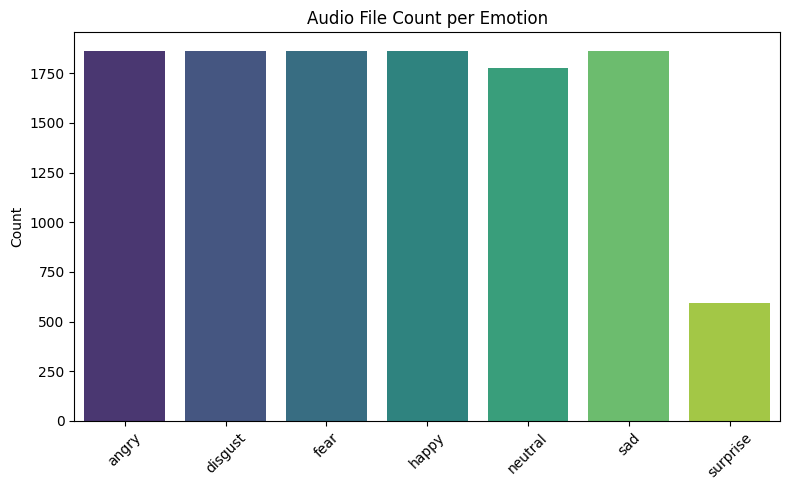

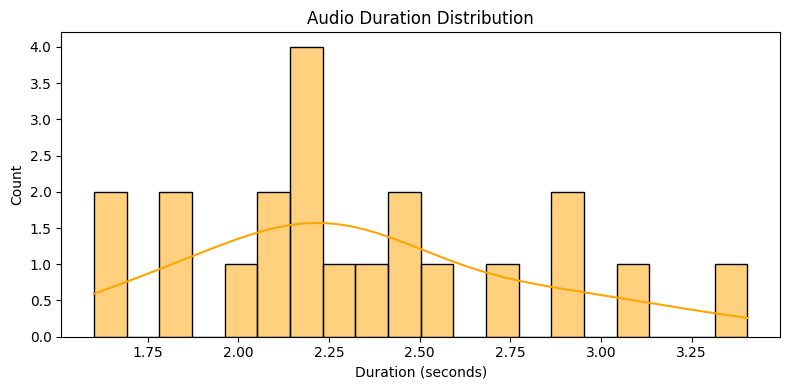

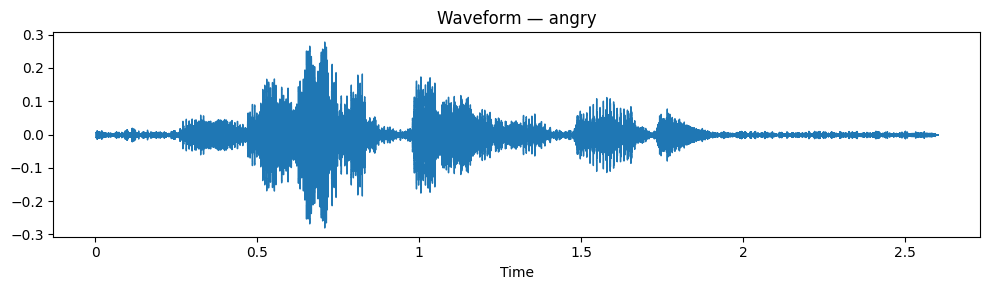

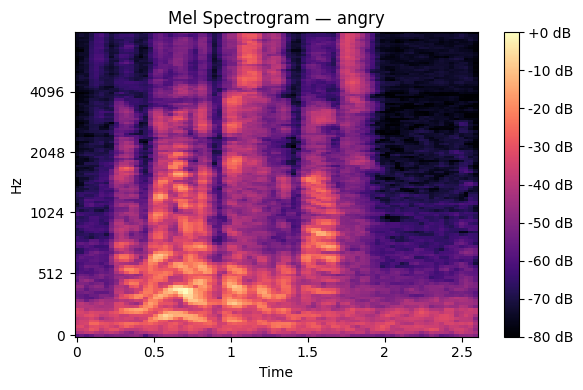

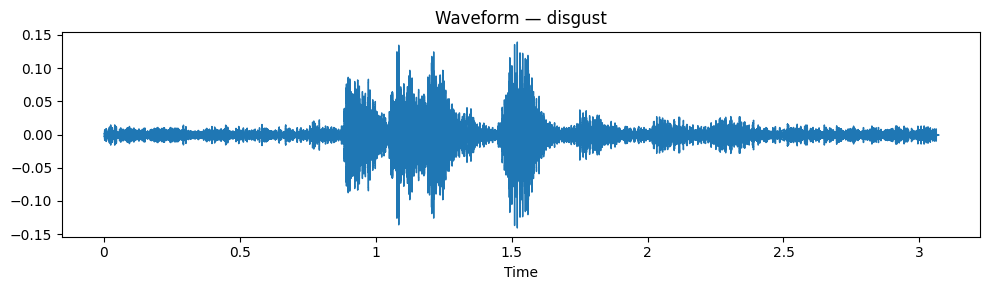

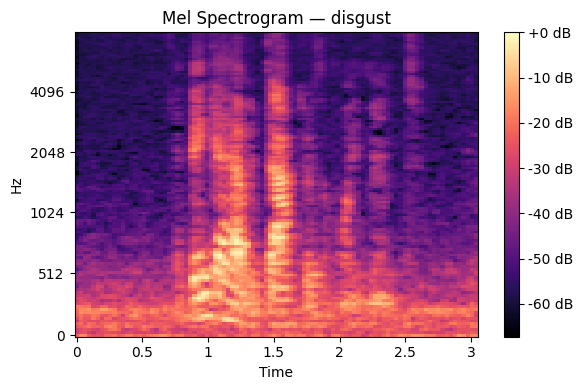

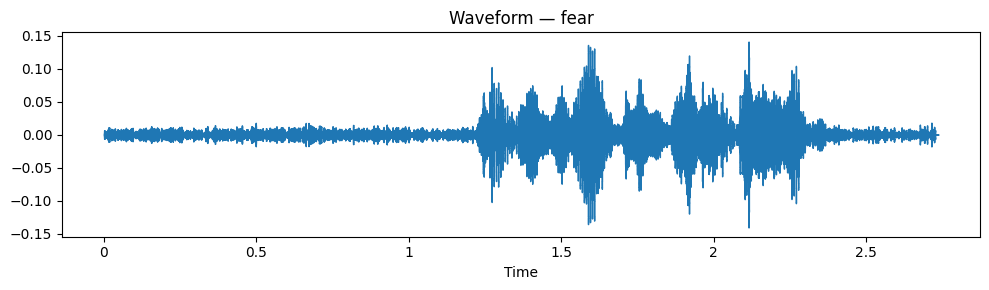

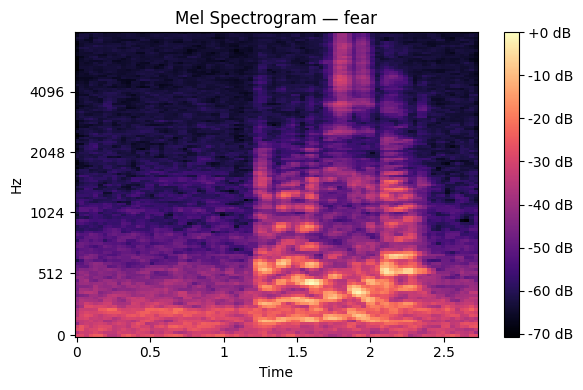

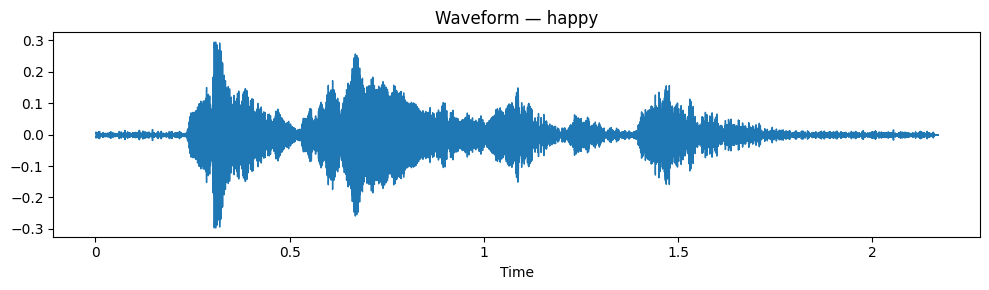

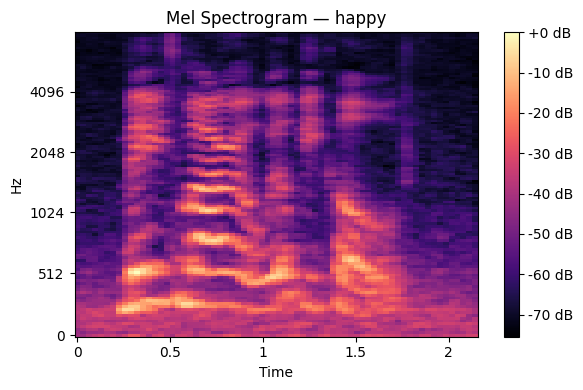

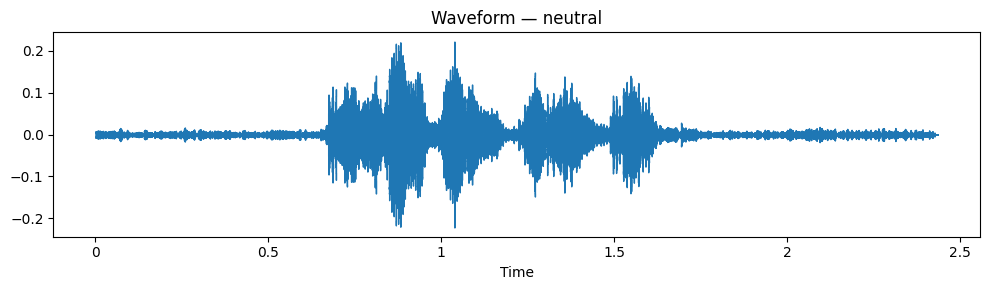

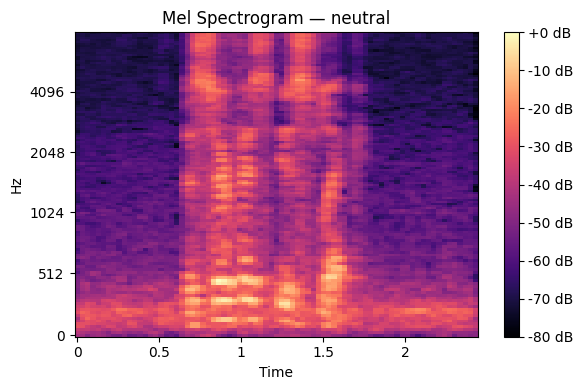

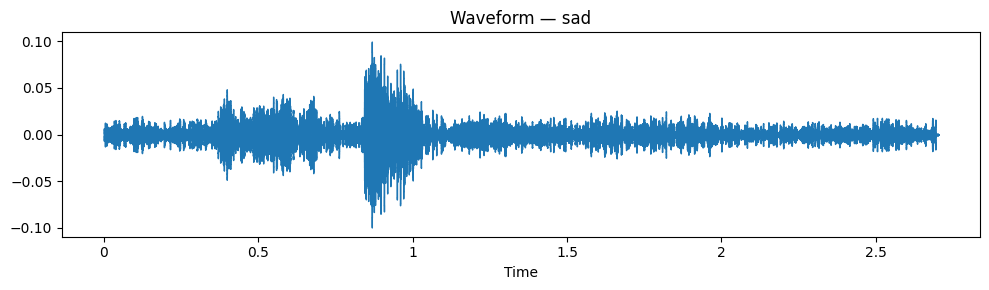

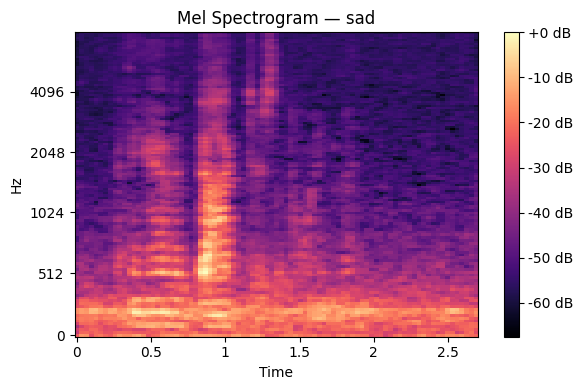

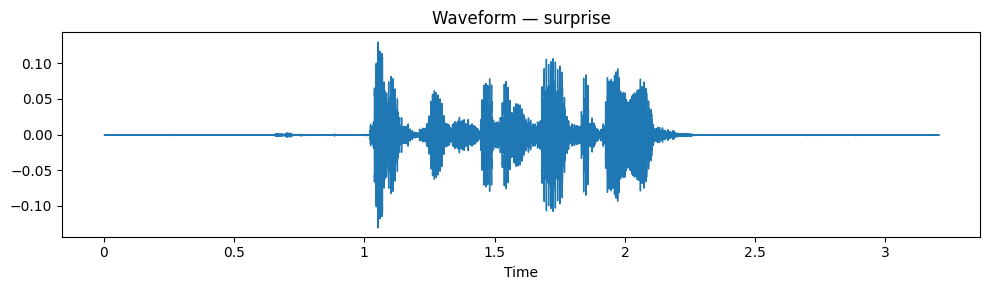

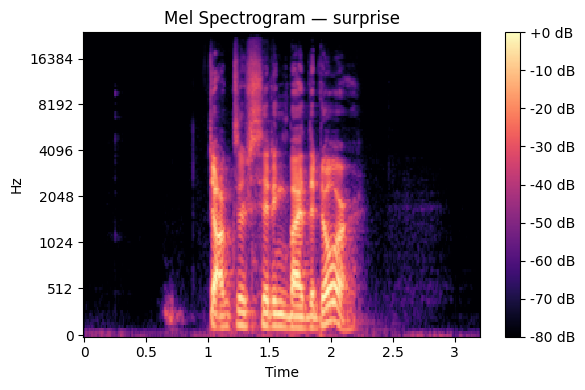

    Emotion  Count  Percentage
0     angry   1863       15.95
1   disgust   1863       15.95
2      fear   1863       15.95
3     happy   1863       15.95
4   neutral   1775       15.19
5       sad   1863       15.95
6  surprise    592        5.07

✅ EDA Completed. Visuals saved to: D:\Emotion Voice\Data\visuals


In [4]:
# ==========================================================
# FILE: 01_EDA_and_Visualization.ipynb
# PHASE 1A — Dataset Exploration & Visualization
# ==========================================================

import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import seaborn as sns
import pandas as pd

# ----------------------------------------------------------
# CONFIG
# ----------------------------------------------------------
RAW_DIR = r"D:\Emotion Voice\Data\raw"
OUTPUT_VIS_DIR = r"D:\Emotion Voice\Data\visuals"
os.makedirs(OUTPUT_VIS_DIR, exist_ok=True)

emotions = sorted([d for d in os.listdir(RAW_DIR) if os.path.isdir(os.path.join(RAW_DIR, d))])

# ----------------------------------------------------------
# Count files per emotion
# ----------------------------------------------------------
file_counts = {}
durations = []

for emotion in emotions:
    folder = os.path.join(RAW_DIR, emotion)
    files = [f for f in os.listdir(folder) if f.lower().endswith('.wav')]
    file_counts[emotion] = len(files)
    
    # take 3 random samples to inspect durations
    for f in np.random.choice(files, min(3, len(files)), replace=False):
        path = os.path.join(folder, f)
        y, sr = librosa.load(path, sr=None)
        durations.append(len(y)/sr)

# ----------------------------------------------------------
# Bar chart of emotion distribution
# ----------------------------------------------------------
plt.figure(figsize=(8,5))
sns.barplot(x=list(file_counts.keys()), y=list(file_counts.values()), palette="viridis")
plt.title("Audio File Count per Emotion")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_VIS_DIR, "emotion_distribution.png"))
plt.show()

# ----------------------------------------------------------
# Duration distribution
# ----------------------------------------------------------
plt.figure(figsize=(8,4))
sns.histplot(durations, bins=20, color="orange", kde=True)
plt.title("Audio Duration Distribution")
plt.xlabel("Duration (seconds)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_VIS_DIR, "duration_distribution.png"))
plt.show()

# ----------------------------------------------------------
# Example waveform & spectrogram per emotion
# ----------------------------------------------------------
for emotion in emotions:
    folder = os.path.join(RAW_DIR, emotion)
    sample_file = np.random.choice(os.listdir(folder))
    path = os.path.join(folder, sample_file)
    
    y, sr = librosa.load(path, sr=None)
    plt.figure(figsize=(10,3))
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"Waveform — {emotion}")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_VIS_DIR, f"waveform_{emotion}.png"))
    plt.show()
    
    # Mel Spectrogram
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    plt.figure(figsize=(6,4))
    librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', cmap='magma')
    plt.title(f"Mel Spectrogram — {emotion}")
    plt.colorbar(format='%+2.0f dB')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_VIS_DIR, f"mel_{emotion}.png"))
    plt.show()

# ----------------------------------------------------------
# Summary
# ----------------------------------------------------------
eda_df = pd.DataFrame({
    "Emotion": list(file_counts.keys()),
    "Count": list(file_counts.values())
})
eda_df["Percentage"] = (eda_df["Count"] / eda_df["Count"].sum() * 100).round(2)
print(eda_df)

print("\n✅ EDA Completed. Visuals saved to:", OUTPUT_VIS_DIR)


In [7]:
# ==========================================================
# FILE: 02_NoiseReduction_Normalization_GPU.ipynb
# PHASE 1B — Clean Audio + GPU Mel Spectrogram Generation
# ==========================================================

import os
import numpy as np
import librosa
import torchaudio
import torch
import soundfile as sf
import noisereduce as nr
import pandas as pd
from tqdm import tqdm
import torch.nn.functional as F

# ----------------------------------------------------------
# CONFIG
# ----------------------------------------------------------
RAW_DIR = r"D:\Emotion Voice\Data\raw"
PROCESSED_DIR = r"D:\Emotion Voice\Data\processed"
CLEAN_WAV_DIR = os.path.join(PROCESSED_DIR, "cleaned_wav")
MEL_DIR = os.path.join(PROCESSED_DIR, "mel_npy")
META_CSV = os.path.join(PROCESSED_DIR, "metadata.csv")

SAMPLE_RATE = 22050
TARGET_DURATION = 4.0  # seconds
TARGET_SAMPLES = int(SAMPLE_RATE * TARGET_DURATION)
N_MELS = 128
HOP_LENGTH = 256
N_FFT = 1024
DESIRED_TIME_FRAMES = 128

os.makedirs(CLEAN_WAV_DIR, exist_ok=True)
os.makedirs(MEL_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🟢 Using device: {device}")

# ----------------------------------------------------------
# Utility Functions
# ----------------------------------------------------------
def safe_audio(y):
    """Clean invalid samples and normalize RMS."""
    y = np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0)
    rms = np.sqrt(np.mean(y**2))
    return y / (rms + 1e-8) if rms > 0 else y

def pad_or_trim(y):
    if len(y) > TARGET_SAMPLES:
        return y[:TARGET_SAMPLES]
    return np.pad(y, (0, TARGET_SAMPLES - len(y)))

# Preload GPU transforms
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS
).to(device)
amp_to_db = torchaudio.transforms.AmplitudeToDB(stype='power').to(device)

metadata = []
emotions = sorted(os.listdir(RAW_DIR))

# ----------------------------------------------------------
# MAIN LOOP
# ----------------------------------------------------------
for emotion in emotions:
    src_dir = os.path.join(RAW_DIR, emotion)
    out_wav = os.path.join(CLEAN_WAV_DIR, emotion)
    out_mel = os.path.join(MEL_DIR, emotion)
    os.makedirs(out_wav, exist_ok=True)
    os.makedirs(out_mel, exist_ok=True)

    files = [f for f in os.listdir(src_dir) if f.lower().endswith('.wav')]
    print(f"\n🎧 Processing {emotion} — {len(files)} files")

    for file in tqdm(files):
        src_path = os.path.join(src_dir, file)
        try:
            # Load via librosa to avoid torchcodec issue
            y, sr = librosa.load(src_path, sr=None)
            if sr != SAMPLE_RATE:
                y = librosa.resample(y, orig_sr=sr, target_sr=SAMPLE_RATE)
                sr = SAMPLE_RATE

            y = safe_audio(y)
            try:
                y = nr.reduce_noise(y=y, sr=sr, prop_decrease=1.0)
            except Exception:
                pass
            y = safe_audio(y)
            y = pad_or_trim(y)

            # Save cleaned wav (optional)
            sf.write(os.path.join(out_wav, file), y, sr)

            # Generate Mel Spectrogram (GPU)
            waveform = torch.tensor(y, dtype=torch.float32).unsqueeze(0).to(device)
            with torch.no_grad():
                mel = mel_transform(waveform)
                mel_db = amp_to_db(mel)
                mel_db_4d = mel_db.unsqueeze(1)
                mel_resized = F.interpolate(mel_db_4d, size=(N_MELS, DESIRED_TIME_FRAMES), mode='bilinear', align_corners=False)
                mel_final = mel_resized.squeeze().cpu().numpy().astype(np.float32)

            np.save(os.path.join(out_mel, file.replace('.wav', '.npy')), mel_final)
            metadata.append({
                "file": file,
                "emotion": emotion,
                "samples": len(y),
                "mel_shape": f"{mel_final.shape}",
                "path": os.path.join(out_mel, file.replace('.wav', '.npy'))
            })
        except Exception as e:
            print(f"⚠️ Error processing {file}: {e}")

# ----------------------------------------------------------
# Save Metadata
# ----------------------------------------------------------
df = pd.DataFrame(metadata)
df.to_csv(META_CSV, index=False)
print("\n✅ Phase 1B Completed.")
print("Metadata saved to:", META_CSV)


🟢 Using device: cuda

🎧 Processing angry — 1863 files


100%|██████████| 1863/1863 [01:44<00:00, 17.88it/s]



🎧 Processing disgust — 1863 files


100%|██████████| 1863/1863 [01:39<00:00, 18.63it/s]



🎧 Processing fear — 1863 files


...


🎧 Processing sad — 1863 files


 67%|██████▋   | 1247/1863 [01:05<00:32, 19.21it/s]c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\noisereduce\spectralgate\nonstationary.py:70: RuntimeWarning: invalid value encountered in divide
  sig_mult_above_thresh = (abs_sig_stft - sig_stft_smooth) / sig_stft_smooth
100%|██████████| 1863/1863 [01:39<00:00, 18.79it/s]



🎧 Processing surprise — 592 files


100%|██████████| 592/592 [00:35<00:00, 16.59it/s]


✅ Phase 1B Completed.
Metadata saved to: D:\Emotion Voice\Data\processed\metadata.csv


In [8]:
import os, numpy as np, pandas as pd

root = r"D:\Emotion Voice\Data\processed\mel_npy"
meta = pd.read_csv(r"D:\Emotion Voice\Data\processed\metadata.csv")

# 1. Confirm per-emotion counts
counts = {emo: len([f for f in os.listdir(os.path.join(root, emo)) if f.endswith(".npy")]) 
          for emo in os.listdir(root)}
print("Counts:", counts)

# 2. Inspect one sample
sample = os.path.join(root, "angry", os.listdir(os.path.join(root, "angry"))[0])
mel = np.load(sample)
print("Sample shape:", mel.shape, "Min:", mel.min(), "Max:", mel.max())

# 3. Quick metadata check
print(meta.head())


Counts: {'angry': 1863, 'disgust': 1863, 'fear': 1863, 'happy': 1863, 'neutral': 1775, 'sad': 1863, 'surprise': 592}
Sample shape: (128, 128) Min: -100.0 Max: 62.6724
                       file emotion  samples   mel_shape  \
0  03-01-05-01-01-01-01.wav   angry    88200  (128, 128)   
1  03-01-05-01-01-01-02.wav   angry    88200  (128, 128)   
2  03-01-05-01-01-01-03.wav   angry    88200  (128, 128)   
3  03-01-05-01-01-01-04.wav   angry    88200  (128, 128)   
4  03-01-05-01-01-01-05.wav   angry    88200  (128, 128)   

                                                path  
0  D:\Emotion Voice\Data\processed\mel_npy\angry\...  
1  D:\Emotion Voice\Data\processed\mel_npy\angry\...  
2  D:\Emotion Voice\Data\processed\mel_npy\angry\...  
3  D:\Emotion Voice\Data\processed\mel_npy\angry\...  
4  D:\Emotion Voice\Data\processed\mel_npy\angry\...  


In [2]:
# =========================================================
# PHASE 1C (NEW CELL) — GAN-based Data Augmentation
# =========================================================
# This cell trains a separate GAN for *each* class to
# augment the dataset to a balanced 2000 samples per class.
# =========================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
import glob
from tqdm import tqdm
import warnings

# --- CONFIG ---
# Direct path from your Phase 1B notebook
BASE_DATA_DIR = r"D:\Emotion Voice\Data\processed\mel_npy"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Original counts from your Phase 1A (Cell 4) output
ORIGINAL_COUNTS = {
    'angry': 1863,
    'disgust': 1863,
    'fear': 1863,
    'happy': 1863,
    'neutral': 1775,
    'sad': 1863,
    'surprise': 592
}
TARGET_COUNT = 2000 # Your target sample count per class

# Calculate how many samples to generate for each class
TARGETS_TO_GENERATE = {
    emo: TARGET_COUNT - count for emo, count in ORIGINAL_COUNTS.items()
}

# GAN Hyperparameters
N_EPOCHS = 150       # 150-200 epochs is a good start
BATCH_SIZE = 64
LR = 0.0002
LATENT_DIM = 100     # Size of the random noise vector (z)
B1 = 0.5             # Adam optimizer beta1
B2 = 0.999           # Adam optimizer beta2

# Spectrogram dimensions from your Phase 1B (Cell 5)
IMG_CHANNELS = 1
IMG_SIZE = 128

warnings.filterwarnings("ignore", category=UserWarning)
print(f"🟢 GAN Augmentation (Target: {TARGET_COUNT}) running on device: {device}")

# --- 1. GAN DATASET (Loads one emotion at a time) ---
class GANDataset(Dataset):
    def __init__(self, directory):
        self.files = glob.glob(os.path.join(directory, '*.npy'))
        
        # Get normalization stats from one sample file
        # This is an approximation but good enough for scaling
        try:
            sample_mel = np.load(self.files[0]).astype(np.float32)
            self.sample_min = sample_mel.min()
            self.sample_max = sample_mel.max()
        except Exception as e:
            print(f"Warning: Could not load sample file for stats. Using defaults. {e}")
            self.sample_min = -100.0
            self.sample_max = 60.0

    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, idx):
        mel = np.load(self.files[idx]).astype(np.float32)
        
        # Normalize to [-1, 1] for GAN training (stable with Tanh)
        mel_norm = 2 * (mel - self.sample_min) / (self.sample_max - self.sample_min + 1e-6) - 1
        
        mel_tensor = torch.tensor(mel_norm).unsqueeze(0) # Add channel dim [1, 128, 128]
        return mel_tensor

# --- 2. GENERATOR MODEL (DCGAN) ---
# Takes 100D noise and upsamples it to a [1, 128, 128] image
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # Input: [B, 100, 1, 1]
            nn.ConvTranspose2d(LATENT_DIM, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            # State: [B, 512, 4, 4]
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # State: [B, 256, 8, 8]
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # State: [B, 128, 16, 16]
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # State: [B, 64, 32, 32]
            nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            # State: [B, 32, 64, 64]
            nn.ConvTranspose2d(32, IMG_CHANNELS, 4, 2, 1, bias=False),
            nn.Tanh() # Output: [B, 1, 128, 128] (normalized -1 to 1)
        )
    def forward(self, z):
        return self.main(z)

# --- 3. DISCRIMINATOR MODEL (DCGAN) ---
# Takes a [1, 128, 128] image and outputs a single value (real/fake)
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Input: [B, 1, 128, 128]
            nn.Conv2d(IMG_CHANNELS, 32, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # State: [B, 32, 64, 64]
            nn.Conv2d(32, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            # State: [B, 64, 32, 32]
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # State: [B, 128, 16, 16]
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            # State: [B, 256, 8, 8]
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            # State: [B, 512, 4, 4]
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid() # Output: [B, 1, 1, 1] -> Squeezed to scalar
        )
    def forward(self, img):
        return self.main(img).view(-1, 1).squeeze(1)

# Function to initialize weights (important for DCGAN)
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# --- 4. MAIN AUGMENTATION LOOP (FOR ALL 7 CLASSES) ---
for emotion_name, n_to_generate in TARGETS_TO_GENERATE.items():
    if n_to_generate <= 0:
        print(f"✅ '{emotion_name}' is already at/above target {TARGET_COUNT}. Skipping.")
        continue
        
    print(f"\n{'='*60}\n🚀 Augmenting '{emotion_name}' class: Generating {n_to_generate} samples\n{'='*60}")
    
    # --- Setup directories and data for this emotion ---
    data_dir = os.path.join(BASE_DATA_DIR, emotion_name)
    output_dir = os.path.join(BASE_DATA_DIR, emotion_name) # Save back to the same folder
    
    gan_dataset = GANDataset(data_dir)
    # Check if dataset is empty or unreadable
    if len(gan_dataset) == 0:
        print(f"⚠️ No .npy files found for '{emotion_name}'. Skipping.")
        continue
        
    gan_loader = DataLoader(gan_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    
    # Get stats from the dataset for de-normalization
    SAMPLE_MIN = gan_dataset.sample_min
    SAMPLE_MAX = gan_dataset.sample_max

    # --- Initialize models and training components ---
    generator = Generator().to(device)
    discriminator = Discriminator().to(device)
    generator.apply(weights_init)
    discriminator.apply(weights_init)

    adversarial_loss = nn.BCELoss() # Binary Cross-Entropy
    optimizer_G = optim.Adam(generator.parameters(), lr=LR, betas=(B1, B2))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=LR, betas=(B1, B2))

    # --- GAN Training Loop ---
    for epoch in range(N_EPOCHS):
        pbar = tqdm(gan_loader, desc=f"GAN Epoch {epoch+1}/{N_EPOCHS} [{emotion_name}]")
        for i, real_mels in enumerate(pbar):
            real_mels = real_mels.to(device)
            batch_s = real_mels.size(0)

            # --- Train Discriminator ---
            optimizer_D.zero_grad()
            
            # Real batch
            label_real = torch.full((batch_s,), 1.0, dtype=torch.float, device=device)
            output_real = discriminator(real_mels)
            loss_D_real = adversarial_loss(output_real, label_real)
            loss_D_real.backward()

            # Fake batch
            noise = torch.randn(batch_s, LATENT_DIM, 1, 1, device=device)
            fake_mels = generator(noise)
            label_fake = torch.full((batch_s,), 0.0, dtype=torch.float, device=device)
            output_fake = discriminator(fake_mels.detach()) # Detach generator
            loss_D_fake = adversarial_loss(output_fake, label_fake)
            loss_D_fake.backward()
            
            loss_D = loss_D_real + loss_D_fake
            optimizer_D.step()

            # --- Train Generator ---
            optimizer_G.zero_grad()
            label_g = torch.full((batch_s,), 1.0, dtype=torch.float, device=device) # Generator wants D to say "real"
            output_g = discriminator(fake_mels) # Don't detach
            loss_G = adversarial_loss(output_g, label_g)
            loss_G.backward()
            optimizer_G.step()
            
            pbar.set_postfix(g_loss=f"{loss_G.item():.3f}", d_loss=f"{loss_D.item():.3f}")

    print(f"✅ GAN Training Complete for '{emotion_name}'.")

    # --- Generate and Save New Samples ---
    print(f"💾 Generating {n_to_generate} new '{emotion_name}' samples...")
    generator.eval()
    with torch.no_grad():
        # Generate in batches for efficiency
        generated_count = 0
        while generated_count < n_to_generate:
            gen_batch_size = min(BATCH_SIZE, n_to_generate - generated_count)
            z = torch.randn(gen_batch_size, LATENT_DIM, 1, 1, device=device)
            fake_mels_norm = generator(z).cpu().numpy()
            
            # De-normalize from [-1, 1] back to the original data's dB range
            fake_mels_scaled = (fake_mels_norm + 1) / 2 * (SAMPLE_MAX - SAMPLE_MIN) + SAMPLE_MIN
            
            for i in range(gen_batch_size):
                if generated_count >= n_to_generate:
                    break
                
                # Get the spectrogram (C, H, W) -> (H, W)
                fake_mel = fake_mels_scaled[i, 0, :, :]
                
                # Save to the *original* emotion directory
                filename = os.path.join(output_dir, f"gan_synth_{generated_count + 1}.npy")
                np.save(filename, fake_mel.astype(np.float32))
                generated_count += 1
                
    print(f"✅ Augmentation complete for '{emotion_name}'.")

print("\n\n🔥🔥🔥 All classes augmented. Dataset is now balanced at {TARGET_COUNT} samples each. 🔥🔥🔥")
print("You can now re-run Phase 1A (EDA) to verify the new counts, then run Phase 2.")

🟢 GAN Augmentation (Target: 2000) running on device: cuda

🚀 Augmenting 'angry' class: Generating 137 samples


GAN Epoch 150/150 [angry]: 100%|██████████| 30/30 [00:02<00:00, 13.17it/s, d_loss=0.405, g_loss=3.259]


✅ GAN Training Complete for 'angry'.
💾 Generating 137 new 'angry' samples...
✅ Augmentation complete for 'angry'.

🚀 Augmenting 'disgust' class: Generating 137 samples


GAN Epoch 150/150 [disgust]: 100%|██████████| 30/30 [00:02<00:00, 14.29it/s, d_loss=0.197, g_loss=3.533]


✅ GAN Training Complete for 'disgust'.
💾 Generating 137 new 'disgust' samples...
✅ Augmentation complete for 'disgust'.

🚀 Augmenting 'fear' class: Generating 137 samples


...

✅ GAN Training Complete for 'neutral'.
💾 Generating 225 new 'neutral' samples...
✅ Augmentation complete for 'neutral'.

🚀 Augmenting 'sad' class: Generating 137 samples


GAN Epoch 150/150 [sad]: 100%|██████████| 30/30 [00:02<00:00, 13.55it/s, d_loss=0.148, g_loss=4.382]


✅ GAN Training Complete for 'sad'.
💾 Generating 137 new 'sad' samples...
✅ Augmentation complete for 'sad'.

🚀 Augmenting 'surprise' class: Generating 1408 samples


GAN Epoch 150/150 [surprise]: 100%|██████████| 10/10 [00:00<00:00, 14.28it/s, d_loss=0.000, g_loss=42.564]


✅ GAN Training Complete for 'surprise'.
💾 Generating 1408 new 'surprise' samples...
✅ Augmentation complete for 'surprise'.


🔥🔥🔥 All classes augmented. Dataset is now balanced at {TARGET_COUNT} samples each. 🔥🔥🔥
You can now re-run Phase 1A (EDA) to verify the new counts, then run Phase 2.


In [3]:
# =========================================================
# PHASE 2 — Tier-0 Optimized GPU Training for 5 Models
# =========================================================
import warnings, os, random, copy
from pathlib import Path
from collections import Counter
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedShuffleSplit

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------- CONFIG ----------------
DATA_ROOT = r"D:\Emotion Voice\Data\processed\mel_npy"
OUTPUT_DIR = r"D:\Emotion Voice\training_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

EPOCHS = 40
BATCH_SIZE = 32
LR = 2e-4
PATIENCE = 6
NUM_WORKERS = 0
MIXED_PRECISION = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)
if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print("cuDNN: deterministic=True, benchmark=False")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# ---------------- DATASET ----------------
def find_classes_and_files(root):
    classes = sorted([d.name for d in Path(root).iterdir() if d.is_dir()])
    class_to_idx = {c: i for i, c in enumerate(classes)}
    files, labels = [], []
    for c in classes:
        for f in Path(root, c).glob("*.npy"):
            files.append(str(f)); labels.append(class_to_idx[c])
    return classes, class_to_idx, files, labels

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files, self.labels = files, labels
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        mel = np.load(self.files[idx]).astype(np.float32)
        mel = (mel - mel.mean()) / (mel.std() + 1e-6)
        mel = np.expand_dims(mel, 0)
        return torch.tensor(mel), torch.tensor(self.labels[idx])

classes, _, files, labels = find_classes_and_files(DATA_ROOT)
n_classes = len(classes)
sss = StratifiedShuffleSplit(1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(sss.split(files, labels))
train_files, val_files = [files[i] for i in train_idx], [files[i] for i in val_idx]
train_labels, val_labels = [labels[i] for i in train_idx], [labels[i] for i in val_idx]

label_counts = Counter(train_labels)
total = sum(label_counts.values())
class_weight_tensor = torch.tensor([total / (n_classes * label_counts[i]) for i in range(n_classes)],
                                   dtype=torch.float32).to(device)
sample_weights = [1.0 / label_counts[l] for l in train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(MelDataset(train_files, train_labels), batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=NUM_WORKERS)
val_loader = DataLoader(MelDataset(val_files, val_labels), batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=NUM_WORKERS)

# ---------------- MODEL FACTORY ----------------
def build_model(model_name, n_classes):
    name = model_name.lower()
    if name == "resnet50":
        m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        m.conv1 = nn.Conv2d(1, 64, 7, 2, 3, bias=False)
        m.fc = nn.Linear(m.fc.in_features, n_classes)
        return m, optim.AdamW, nn.LeakyReLU(0.1)
    if name == "efficientnet_v2_m":
        m = models.efficientnet_v2_m(weights=models.EfficientNet_V2_M_Weights.IMAGENET1K_V1)
        m.features[0][0] = nn.Conv2d(1, m.features[0][0].out_channels, 3, 2, 1, bias=False)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, n_classes)
        return m, optim.AdamW, nn.SiLU()
    if name == "mobilenet_v2":
        m = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        m.features[0][0] = nn.Conv2d(1, m.features[0][0].out_channels, 3, 2, 1, bias=False)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, n_classes)
        return m, optim.Adam, nn.ReLU6(inplace=True)
    if name == "densenet121":
        m = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        m.features.conv0 = nn.Conv2d(1, 64, 7, 2, 3, bias=False)
        m.classifier = nn.Linear(m.classifier.in_features, n_classes)
        return m, optim.Adam, nn.ReLU(inplace=True)
    if name == "vgg16":
        m = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        m.features[0] = nn.Conv2d(1, 64, 3, padding=1)
        m.classifier[6] = nn.Linear(m.classifier[6].in_features, n_classes)
        return m, lambda params, lr: optim.SGD(params, lr=lr, momentum=0.9), nn.ReLU(inplace=True)
    raise ValueError(f"Unknown model: {model_name}")

# ---------------- TRAIN + EVAL ----------------
def evaluate(model, loader, criterion):
    model.eval(); preds, trues, loss_sum = [], [], 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            with autocast(enabled=MIXED_PRECISION):
                out = model(x)
                loss = criterion(out, y)
            loss_sum += loss.item() * x.size(0)
            preds.extend(out.argmax(1).cpu().numpy())
            trues.extend(y.cpu().numpy())
    acc = accuracy_score(trues, preds)
    f1 = f1_score(trues, preds, average="weighted")
    return loss_sum / len(loader.dataset), acc, f1

models_to_train = ["resnet50", "efficientnet_v2_m", "mobilenet_v2", "densenet121", "vgg16"]
summary = []

for model_name in models_to_train:
    print(f"\n{'='*80}\n🚀 Training {model_name.upper()}\n{'='*80}")
    model, optim_fn, act_fn = build_model(model_name, n_classes)
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weight_tensor)
    optimizer = optim_fn(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    scaler = GradScaler(enabled=MIXED_PRECISION)

    best_f1, patience_counter, best_state = -1, 0, None

    for epoch in range(1, EPOCHS+1):
        model.train()
        total_loss, total_samples = 0, 0
        pbar = tqdm(train_loader, desc=f"[{model_name}] Epoch {epoch}/{EPOCHS}")
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            with autocast(enabled=MIXED_PRECISION):
                out = model(x)
                loss = criterion(out, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item() * x.size(0)
            total_samples += x.size(0)
            pbar.set_postfix(loss=f"{total_loss/total_samples:.4f}")

        val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion)
        print(f"Epoch {epoch}: val_acc={val_acc:.4f}, val_f1={val_f1:.4f}")
        scheduler.step(val_loss)

        if val_f1 > best_f1:
            best_f1, patience_counter = val_f1, 0
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, os.path.join(OUTPUT_DIR, f"best_{model_name}.pt"))
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"⛔ Early stopping (best F1={best_f1:.4f})")
                break

    model.load_state_dict(best_state)
    final_loss, final_acc, final_f1 = evaluate(model, val_loader, criterion)
    summary.append({"Model": model_name, "Val_Acc": final_acc, "Val_F1": final_f1})
    print(f"✅ {model_name}: Acc={final_acc:.4f}, F1={final_f1:.4f}")

summary_df = pd.DataFrame(summary)
summary_df.to_csv(os.path.join(OUTPUT_DIR, "MODEL_SUMMARY_5_MODELS.csv"), index=False)
print("\n🏁 Training Finished — Summary:\n", summary_df)


Using device: cuda
cuDNN: deterministic=True, benchmark=False

🚀 Training RESNET50


[resnet50] Epoch 1/40: 100%|██████████| 293/293 [00:20<00:00, 14.54it/s, loss=0.9034]


Epoch 1: val_acc=0.5862, val_f1=0.5781


[resnet50] Epoch 2/40: 100%|██████████| 293/293 [00:20<00:00, 14.29it/s, loss=0.6162]


Epoch 2: val_acc=0.6264, val_f1=0.6113


...

Epoch 26: val_acc=0.6786, val_f1=0.6765


[vgg16] Epoch 27/40: 100%|██████████| 293/293 [00:30<00:00,  9.59it/s, loss=0.3167]


Epoch 27: val_acc=0.7013, val_f1=0.6969


[vgg16] Epoch 28/40: 100%|██████████| 293/293 [00:30<00:00,  9.57it/s, loss=0.2818]


Epoch 28: val_acc=0.6936, val_f1=0.6907
⛔ Early stopping (best F1=0.7033)
✅ vgg16: Acc=0.7073, F1=0.7033

🏁 Training Finished — Summary:
                Model   Val_Acc    Val_F1
0           resnet50  0.701326  0.700165
1  efficientnet_v2_m  0.709457  0.710360
2       mobilenet_v2  0.666667  0.665423
3        densenet121  0.702610  0.701922
4              vgg16  0.707317  0.703323


In [1]:
# =========================================================
# PHASE 2 — Tier-0 Optimized GPU Training for 5 Models
# =========================================================
import warnings, os, random, copy
from pathlib import Path
from collections import Counter
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedShuffleSplit

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------- CONFIG ----------------
DATA_ROOT = r"D:\Emotion Voice\Data\processed\mel_npy"
OUTPUT_DIR = r"D:\Emotion Voice\training_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

EPOCHS = 40
BATCH_SIZE = 32
LR = 2e-4
PATIENCE = 6
NUM_WORKERS = 0
MIXED_PRECISION = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# <<< CHANGED: Added L1 and L2 regularization parameters
L1_LAMBDA = 1e-5       # Penalty strength for L1 (manual loss)
L2_WEIGHT_DECAY = 1e-4 # Penalty strength for L2 (optimizer)

print("Using device:", device)
if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print("cuDNN: deterministic=True, benchmark=False")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# ---------------- DATASET ----------------
def find_classes_and_files(root):
    classes = sorted([d.name for d in Path(root).iterdir() if d.is_dir()])
    class_to_idx = {c: i for i, c in enumerate(classes)}
    files, labels = [], []
    for c in classes:
        for f in Path(root, c).glob("*.npy"):
            files.append(str(f)); labels.append(class_to_idx[c])
    return classes, class_to_idx, files, labels

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files, self.labels = files, labels
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        mel = np.load(self.files[idx]).astype(np.float32)
        mel = (mel - mel.mean()) / (mel.std() + 1e-6)
        mel = np.expand_dims(mel, 0)
        return torch.tensor(mel), torch.tensor(self.labels[idx])

classes, _, files, labels = find_classes_and_files(DATA_ROOT)
n_classes = len(classes)
sss = StratifiedShuffleSplit(1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(sss.split(files, labels))
train_files, val_files = [files[i] for i in train_idx], [files[i] for i in val_idx]
train_labels, val_labels = [labels[i] for i in train_idx], [labels[i] for i in val_idx]

label_counts = Counter(train_labels)
total = sum(label_counts.values())
class_weight_tensor = torch.tensor([total / (n_classes * label_counts[i]) for i in range(n_classes)],
                                   dtype=torch.float32).to(device)
sample_weights = [1.0 / label_counts[l] for l in train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(MelDataset(train_files, train_labels), batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=NUM_WORKERS)
val_loader = DataLoader(MelDataset(val_files, val_labels), batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=NUM_WORKERS)

# ---------------- MODEL FACTORY ----------------
def build_model(model_name, n_classes):
    name = model_name.lower()
    if name == "resnet50":
        m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        m.conv1 = nn.Conv2d(1, 64, 7, 2, 3, bias=False)
        m.fc = nn.Linear(m.fc.in_features, n_classes)
        return m, optim.AdamW, nn.LeakyReLU(0.1)
    if name == "efficientnet_v2_m":
        m = models.efficientnet_v2_m(weights=models.EfficientNet_V2_M_Weights.IMAGENET1K_V1)
        m.features[0][0] = nn.Conv2d(1, m.features[0][0].out_channels, 3, 2, 1, bias=False)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, n_classes)
        return m, optim.AdamW, nn.SiLU()
    if name == "mobilenet_v2":
        m = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        m.features[0][0] = nn.Conv2d(1, m.features[0][0].out_channels, 3, 2, 1, bias=False)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, n_classes)
        return m, optim.Adam, nn.ReLU6(inplace=True)
    if name == "densenet121":
        m = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        m.features.conv0 = nn.Conv2d(1, 64, 7, 2, 3, bias=False)
        m.classifier = nn.Linear(m.classifier.in_features, n_classes)
        return m, optim.Adam, nn.ReLU(inplace=True)
    if name == "vgg16":
        m = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        m.features[0] = nn.Conv2d(1, 64, 3, padding=1)
        m.classifier[6] = nn.Linear(m.classifier[6].in_features, n_classes)
        # <<< CHANGED: Modified VGG16's lambda to accept **kwargs
        # This allows us to pass 'weight_decay' to it like the other optimizers
        return m, lambda params, lr, **kwargs: optim.SGD(params, lr=lr, momentum=0.9, **kwargs), nn.ReLU(inplace=True)
    raise ValueError(f"Unknown model: {model_name}")

# ---------------- TRAIN + EVAL ----------------
def evaluate(model, loader, criterion):
    model.eval(); preds, trues, loss_sum = [], [], 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            with autocast(enabled=MIXED_PRECISION):
                out = model(x)
                loss = criterion(out, y) # Note: We don't add L1/L2 to validation loss
            loss_sum += loss.item() * x.size(0)
            preds.extend(out.argmax(1).cpu().numpy())
            trues.extend(y.cpu().numpy())
    acc = accuracy_score(trues, preds)
    f1 = f1_score(trues, preds, average="weighted")
    return loss_sum / len(loader.dataset), acc, f1

models_to_train = ["resnet50", "efficientnet_v2_m", "mobilenet_v2", "densenet121", "vgg16"]
summary = []

for model_name in models_to_train:
    print(f"\n{'='*80}\n🚀 Training {model_name.upper()}\n{'='*80}")
    model, optim_fn, act_fn = build_model(model_name, n_classes)
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weight_tensor)
    
    # <<< CHANGED: Added L2_WEIGHT_DECAY to the optimizer creation
    optimizer = optim_fn(model.parameters(), lr=LR, weight_decay=L2_WEIGHT_DECAY)
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    scaler = GradScaler(enabled=MIXED_PRECISION)

    best_f1, patience_counter, best_state = -1, 0, None

    for epoch in range(1, EPOCHS+1):
        model.train()
        total_loss, total_samples = 0, 0
        pbar = tqdm(train_loader, desc=f"[{model_name}] Epoch {epoch}/{EPOCHS}")
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            with autocast(enabled=MIXED_PRECISION):
                out = model(x)
                loss = criterion(out, y)
                
                # <<< CHANGED: Manually add L1 regularization penalty to the loss
                if L1_LAMBDA > 0:
                    l1_penalty = torch.tensor(0.0, device=device)
                    for param in model.parameters():
                        if param.requires_grad:
                            l1_penalty += torch.abs(param).sum()
                    loss += L1_LAMBDA * l1_penalty

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item() * x.size(0)
            total_samples += x.size(0)
            pbar.set_postfix(loss=f"{total_loss/total_samples:.4f}")

        val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion)
        print(f"Epoch {epoch}: val_acc={val_acc:.4f}, val_f1={val_f1:.4f}")
        scheduler.step(val_loss)

        if val_f1 > best_f1:
            best_f1, patience_counter = val_f1, 0
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, os.path.join(OUTPUT_DIR, f"best_{model_name}.pt"))
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"⛔ Early stopping (best F1={best_f1:.4f})")
                break

    model.load_state_dict(best_state)
    final_loss, final_acc, final_f1 = evaluate(model, val_loader, criterion)
    summary.append({"Model": model_name, "Val_Acc": final_acc, "Val_F1": final_f1})
    print(f"✅ {model_name}: Acc={final_acc:.4f}, F1={final_f1:.4f}")

summary_df = pd.DataFrame(summary)
summary_df.to_csv(os.path.join(OUTPUT_DIR, "MODEL_SUMMARY_5_MODELS.csv"), index=False)
print("\n🏁 Training Finished — Summary:\n", summary_df)

Using device: cuda
cuDNN: deterministic=True, benchmark=False

🚀 Training RESNET50


[resnet50] Epoch 1/40: 100%|██████████| 293/293 [01:32<00:00,  3.16it/s, loss=3.6153]


Epoch 1: val_acc=0.5884, val_f1=0.5829


[resnet50] Epoch 2/40: 100%|██████████| 293/293 [00:34<00:00,  8.37it/s, loss=3.1846]


Epoch 2: val_acc=0.6080, val_f1=0.6007


...

Epoch 24: val_acc=0.6538, val_f1=0.6497


[vgg16] Epoch 25/40: 100%|██████████| 293/293 [01:20<00:00,  3.63it/s, loss=7.6286]


Epoch 25: val_acc=0.6632, val_f1=0.6609


[vgg16] Epoch 26/40: 100%|██████████| 293/293 [01:26<00:00,  3.39it/s, loss=7.6043]


Epoch 26: val_acc=0.6551, val_f1=0.6548
⛔ Early stopping (best F1=0.6613)
✅ vgg16: Acc=0.6611, F1=0.6613

🏁 Training Finished — Summary:
                Model   Val_Acc    Val_F1
0           resnet50  0.683355  0.682895
1  efficientnet_v2_m  0.718870  0.717476
2       mobilenet_v2  0.657681  0.655521
3        densenet121  0.689773  0.690370
4              vgg16  0.661104  0.661272


In [10]:
# =========================================================
# PHASE 3 — ENSEMBLE SEARCH & FINAL MODEL EXPORT (TIER-0)
# =========================================================
# Description:
#  • Loads best checkpoints from Phase 2
#  • Evaluates each independently
#  • Builds all 2- and 3-model ensembles
#  • Selects highest-F1 configuration
#  • Exports best model as TorchScript + ONNX (with safe fallbacks)
# =========================================================

import os, glob, json, torch, numpy as np, pandas as pd
from pathlib import Path
from itertools import combinations
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torchvision import models
from tqdm import tqdm

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
DATA_ROOT = r"D:\Emotion Voice\Data\processed\mel_npy"
CHECKPOINT_DIR = r"D:\Emotion Voice\training_outputs"
OUTPUT_DIR = r"D:\Emotion Voice\phase3_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🟢 Using device: {DEVICE}")

# ---------------------------------------------------------
# CHECKPOINT DISCOVERY
# ---------------------------------------------------------
def find_best_ckpt(name):
    matches = glob.glob(os.path.join(CHECKPOINT_DIR, f"best_{name}*.pt"))
    return matches[0] if matches else None

TOP_MODELS = [
    ("efficientnet_v2_m", find_best_ckpt("efficientnet_v2_m")),
    ("vgg16", find_best_ckpt("vgg16")),
    ("densenet121", find_best_ckpt("densenet121")),
]

# ---------------------------------------------------------
# DATASET
# ---------------------------------------------------------
def find_classes_and_files(root):
    classes = sorted([d.name for d in Path(root).iterdir() if d.is_dir()])
    class_to_idx = {c: i for i, c in enumerate(classes)}
    files, labels = [], []
    for c in classes:
        for f in Path(root, c).glob("*.npy"):
            files.append(str(f))
            labels.append(class_to_idx[c])
    return classes, class_to_idx, files, labels


class MelDataset(torch.utils.data.Dataset):
    def __init__(self, files, labels):
        self.files, self.labels = files, labels
    def __len__(self): return len(self.files)
    def __getitem__(self, i):
        mel = np.load(self.files[i]).astype(np.float32)
        mel = (mel - mel.mean()) / (mel.std() + 1e-6)
        mel = np.expand_dims(mel, 0)
        return torch.tensor(mel), torch.tensor(self.labels[i])


classes, class_to_idx, files, labels = find_classes_and_files(DATA_ROOT)
n_classes = len(classes)
print("📂 Classes:", classes)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
_, val_idx = next(sss.split(files, labels))
val_ds = MelDataset([files[i] for i in val_idx], [labels[i] for i in val_idx])
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=32, shuffle=False)

# ---------------------------------------------------------
# MODEL LOAD
# ---------------------------------------------------------
def load_model(name, ckpt_path, n_classes):
    if not ckpt_path or not os.path.exists(ckpt_path):
        print(f"⚠️ Missing checkpoint: {name}")
        return None
    try:
        if name == "efficientnet_v2_m":
            m = models.efficientnet_v2_m()
            m.features[0][0] = torch.nn.Conv2d(1, m.features[0][0].out_channels, 3, stride=2, padding=1, bias=False)
            m.classifier[1] = torch.nn.Linear(m.classifier[1].in_features, n_classes)
        elif name == "vgg16":
            m = models.vgg16()
            m.features[0] = torch.nn.Conv2d(1, 64, 3, padding=1)
            m.classifier[6] = torch.nn.Linear(m.classifier[6].in_features, n_classes)
        elif name == "densenet121":
            m = models.densenet121()
            m.features.conv0 = torch.nn.Conv2d(1, 64, 7, stride=2, padding=3, bias=False)
            m.classifier = torch.nn.Linear(m.classifier.in_features, n_classes)
        else:
            return None

        state = torch.load(ckpt_path, map_location=DEVICE)
        if "state_dict" in state:
            state = state["state_dict"]
        m.load_state_dict(state, strict=False)
        m.to(DEVICE).eval()
        print(f"✅ Loaded {name}")
        return m
    except Exception as e:
        print(f"❌ Failed to load {name}: {e}")
        return None

# ---------------------------------------------------------
# EVAL HELPERS
# ---------------------------------------------------------
def get_probs(model, loader):
    ps, ys = [], []
    with torch.no_grad():
        for x, y in tqdm(loader, desc=f"Eval {type(model).__name__}"):
            x = x.to(DEVICE)
            out = F.softmax(model(x), dim=1)
            ps.append(out.cpu().numpy())
            ys.extend(y.numpy())
    return np.concatenate(ps), np.array(ys)


def evaluate(probs, trues):
    preds = probs.argmax(1)
    return accuracy_score(trues, preds), f1_score(trues, preds, average="weighted"), preds


def plot_cm(trues, preds, title, path):
    cm = confusion_matrix(trues, preds)
    plt.figure(figsize=(7, 6))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(path)
    plt.close()

# ---------------------------------------------------------
# LOAD MODELS
# ---------------------------------------------------------
loaded = [(n, m) for n, p in TOP_MODELS if (m := load_model(n, p, n_classes))]
if not loaded: raise RuntimeError("No valid models found")

# ---------------------------------------------------------
# SINGLE-MODEL EVAL
# ---------------------------------------------------------
independent, probs_store = [], {}
for n, m in loaded:
    p, t = get_probs(m, val_loader)
    acc, f1, preds = evaluate(p, t)
    print(f"📊 {n}: acc={acc:.4f}, f1={f1:.4f}")
    probs_store[n] = (p, t)
    plot_cm(t, preds, n, os.path.join(OUTPUT_DIR, f"{n}_cm.png"))
    independent.append(dict(Model=n, Type="Single", Val_Acc=acc, Val_F1=f1))
pd.DataFrame(independent).to_csv(os.path.join(OUTPUT_DIR, "independent.csv"), index=False)

# ---------------------------------------------------------
# ENSEMBLE EVAL
# ---------------------------------------------------------
def avg_probs(arrs): return np.mean(arrs, axis=0)
combination_rows, names = [], [n for n, _ in loaded]

for r in [2, 3]:
    for combo in combinations(names, r):
        arr = [probs_store[n][0] for n in combo]
        t = probs_store[combo[0]][1]
        acc, f1, preds = evaluate(avg_probs(arr), t)
        combo_name = "+".join(combo)
        print(f"🤝 {combo_name}: acc={acc:.4f}, f1={f1:.4f}")
        plot_cm(t, preds, combo_name, os.path.join(OUTPUT_DIR, f"{combo_name}_cm.png"))
        combination_rows.append(dict(Model=combo_name, Type="Ensemble", Val_Acc=acc, Val_F1=f1))

ensemble_df = pd.DataFrame(combination_rows)
ensemble_df.to_csv(os.path.join(OUTPUT_DIR, "ensemble.csv"), index=False)

# ---------------------------------------------------------
# PICK BEST
# ---------------------------------------------------------
df = pd.concat([pd.DataFrame(independent), ensemble_df])
best = df.loc[df.Val_F1.idxmax()]
print("\n🏁 Best Configuration\n", best)
json.dump(best.to_dict(), open(os.path.join(OUTPUT_DIR, "best.json"), "w"), indent=4)

# ---------------------------------------------------------
# EXPORT
# ---------------------------------------------------------
EXPORT = os.path.join(OUTPUT_DIR, "final_export")
os.makedirs(EXPORT, exist_ok=True)

if best.Type == "Single":
    model_to_export = dict(loaded)[best.Model]
else:
    selected = best.Model.split("+")
    class Ensemble(torch.nn.Module):
        def __init__(self, models): super().__init__(); self.models = torch.nn.ModuleList(models)
        def forward(self, x):
            outs = [F.softmax(m(x), dim=1) for m in self.models]
            return torch.mean(torch.stack(outs), dim=0)
    model_to_export = Ensemble([dict(loaded)[n] for n in selected])

model_to_export.to("cpu").float().eval()
dummy = torch.randn(1, 1, 128, 128).float()

ts_path = os.path.join(EXPORT, f"best_{best.Model}.pt")
onnx_path = os.path.join(EXPORT, f"best_{best.Model}.onnx")

# TorchScript
try:
    print("\n🧩 Exporting TorchScript...")
    traced = torch.jit.trace(model_to_export, dummy)
    traced.save(ts_path)
    print(f"✅ TorchScript saved: {ts_path}")
except Exception as e:
    print(f"❌ TorchScript export failed: {e}")


print("\n🔥 Phase 3 complete — best model ready for deployment.")


🟢 Using device: cuda
📂 Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
✅ Loaded efficientnet_v2_m
✅ Loaded vgg16
✅ Loaded densenet121


Eval EfficientNet: 100%|██████████| 74/74 [00:09<00:00,  7.46it/s]


📊 efficientnet_v2_m: acc=0.7099, f1=0.7109


Eval VGG: 100%|██████████| 74/74 [00:06<00:00, 10.80it/s]


📊 vgg16: acc=0.7069, f1=0.7028


Eval DenseNet: 100%|██████████| 74/74 [00:04<00:00, 18.10it/s]


📊 densenet121: acc=0.7022, f1=0.7015
🤝 efficientnet_v2_m+vgg16: acc=0.7296, f1=0.7297
🤝 efficientnet_v2_m+densenet121: acc=0.7266, f1=0.7271
🤝 vgg16+densenet121: acc=0.7287, f1=0.7275
🤝 efficientnet_v2_m+vgg16+densenet121: acc=0.7441, f1=0.7442

🏁 Best Configuration
 Model      efficientnet_v2_m+vgg16+densenet121
Type                                  Ensemble
Val_Acc                               0.744116
Val_F1                                0.744173
Name: 3, dtype: object

🧩 Exporting TorchScript...
✅ TorchScript saved: D:\Emotion Voice\phase3_outputs\final_export\best_efficientnet_v2_m+vgg16+densenet121.pt

🔥 Phase 3 complete — best model ready for deployment.
